# 10 Reducing the keyword bias (mitigation experiment)

CSE 4889 Machine Learning: Explainable Multi-Label Hate Speech Detection in Transliterated Bangla

The bias test showed that the model flags harmless sentences because of words that are common in insults. The reason is in the training data: these words almost always appear in hate comments, so the model rarely sees them used harmlessly.

Here we try a simple fix that uses only the existing training data. We find the words that appear mostly in hate comments, and show the non-hate training comments containing them more often during training (oversampling). Everything else is exactly the same as the main model (same settings, seed and training loop), so any difference comes from the oversampling.

The main model stays our main result. This second model is a mitigation experiment, and we compare the two on:
- the normal test results (does accuracy drop?),
- the harmless probe sentences from the bias test (does the bias go down?),
- the real non-hate test comments that contain these words.

The probe sentences are never used for training or for choosing the words, so the bias test stays fair.

Runtime: T4 GPU (about 25 minutes).

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check the GPU

In [2]:
import torch
assert torch.cuda.is_available(), 'No GPU. Go to Runtime > Change runtime type > T4 GPU, then run again.'
device = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))

GPU: Tesla T4


## Imports, paths and seed

Same seed (42) and the same model code as the main training notebook.

In [3]:
import os
import re
import sys
import json
import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR
from transformers import AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, hamming_loss

BASE = '/content/drive/MyDrive/ML_Project'
SEED = 42
NOTEBOOK_NAME = '10_debias_training.ipynb'
PROC_DIR = os.path.join(BASE, 'data', 'processed')
FIG_DIR = os.path.join(BASE, 'results', 'figures')
TAB_DIR = os.path.join(BASE, 'results', 'tables')
REP_DIR = os.path.join(BASE, 'results', 'evaluation_reports')
CKPT_DIR = os.path.join(BASE, 'results', 'model_checkpoints')
OUT_DIR = os.path.join(CKPT_DIR, 'debiased')
os.makedirs(OUT_DIR, exist_ok=True)
ASSETS_PATH = os.path.join(BASE, 'results', 'ASSETS.md')
sys.path.append(os.path.join(BASE, 'src'))
from model import DualHeadClassifier, CATEGORIES

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
HATE_COL, TARGET_COLS = 'Label', CATEGORIES

## Helper functions

Save tables as CSV and LaTeX, and add files to ASSETS.md.

In [4]:
def save_table(df, name, float_format='%.2f'):
    df.to_csv(os.path.join(TAB_DIR, f'{name}.csv'), index=False)
    df.to_latex(os.path.join(TAB_DIR, f'{name}.tex'), index=False, escape=True,
                float_format=float_format, na_rep='--')
    print('Saved:', name, '(.csv and .tex)')

def register_asset(asset_id, file_name, what, notebook, section, caption):
    row = f'| {asset_id} | {file_name} | {what} | {notebook} | {section} | {caption} |'
    with open(ASSETS_PATH, encoding='utf-8') as f:
        lines = f.read().splitlines()
    lines = [l for l in lines if not l.startswith(f'| {asset_id} |')]
    lines.append(row)
    with open(ASSETS_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines) + '\n')
    print('Registered', asset_id, '->', file_name)

def norm_tokens(text):
    return [re.sub(r'[^\w]', '', t.lower()) for t in str(text).split()]

## Load the data and the main model's settings

We use the same cleaned splits and the same settings as the main model (read from its saved config), so the only change is the oversampling.

In [5]:
def load_split(name):
    return pd.read_csv(os.path.join(PROC_DIR, f'{name}.csv'), keep_default_na=False)

train_df, val_df, test_df = load_split('train'), load_split('validation'), load_split('test')
with open(os.path.join(REP_DIR, 'metrics_training.json')) as f:
    main_metrics = json.load(f)
CONFIG = dict(main_metrics['config'])
MAX_LEN = CONFIG['max_length']
print(CONFIG)

{'model_name': 'xlm-roberta-base', 'batch_size': 32, 'eval_batch_size': 64, 'learning_rate': 2e-05, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'max_epochs': 5, 'patience': 2, 'dropout': 0.1, 'grad_clip': 1.0, 'fp16': True, 'seed': 42, 'max_length': 128}


## Find the words that appear mostly in hate comments (T25)

We count every word in the training comments. A word is on the list if it appears in at least 20 training comments and at least 60% of those comments are hate. The whole training set is 28.4% hate, so these words are strongly tied to hate. Only the training data is used here, not the probe sentences.

In [6]:
MIN_COUNT, MIN_HATE_RATE = 20, 0.60
train_tokens = train_df['clean_text'].map(lambda t: set(norm_tokens(t)))
counts, hate_counts = {}, {}
for toks, y in zip(train_tokens, train_df[HATE_COL]):
    for t in toks:
        if len(t) < 3:
            continue
        counts[t] = counts.get(t, 0) + 1
        hate_counts[t] = hate_counts.get(t, 0) + int(y)
hate_words = sorted([t for t, n in counts.items() if n >= MIN_COUNT and hate_counts[t] / n >= MIN_HATE_RATE],
                    key=lambda t: -hate_counts[t] / counts[t])
word_table = pd.DataFrame({'Word': hate_words,
                           'Training comments': [counts[t] for t in hate_words],
                           'Hate rate (%)': [100 * hate_counts[t] / counts[t] for t in hate_words],
                           'Non-hate comments': [counts[t] - hate_counts[t] for t in hate_words]})
print(len(hate_words), 'words selected')
display(word_table.head(30))
save_table(word_table, 'tab_25_hate_associated_words', float_format='%.1f')
register_asset('T25', 'tables/tab_25_hate_associated_words.csv (+ .tex)',
               f'Training words in at least {MIN_COUNT} comments with a hate rate of at least {int(MIN_HATE_RATE * 100)}%, used for oversampling',
               NOTEBOOK_NAME, 'IV. Methodology (bias mitigation) / Appendix',
               f'TABLE X. Words strongly associated with hate in the training split (at least {MIN_COUNT} comments, hate rate of at least {int(MIN_HATE_RATE * 100)}%).')

99 words selected


,Word,Training comments,Hate rate (%),Non-hate comments
0,nunu,23,100.000000,0
1,pula,40,97.500000,1
2,khanki,40,97.500000,1
3,kankir,33,96.969697,1
4,khankir,117,96.581197,4
5,polara,23,95.652174,1
6,notir,42,95.238095,2
7,kuttar,123,94.308943,7
8,magir,116,93.965517,7
9,pola,220,89.545455,23


Saved: tab_25_hate_associated_words (.csv and .tex)
Registered T25 -> tables/tab_25_hate_associated_words.csv (+ .tex)


## Oversample the non-hate comments that contain these words

Every non-hate training comment that contains at least one listed word is repeated 3 extra times, so the model sees it 4 times per epoch. Hate comments and all other comments are unchanged. The validation and test sets are not changed at all.

In [7]:
REPEAT = 3
hate_set = set(hate_words)
has_word = train_tokens.map(lambda toks: bool(toks & hate_set))
to_repeat = train_df[(train_df[HATE_COL] == 0) & has_word]
aug_train = pd.concat([train_df] + [to_repeat] * REPEAT, ignore_index=True)
print(f'Non-hate comments with a listed word: {len(to_repeat)}')
print(f'Training rows: {len(train_df)} -> {len(aug_train)}')

Non-hate comments with a listed word: 1307
Training rows: 29879 -> 33800


## Data loaders, model, loss and optimizer

The same code as the main training notebook: the dual-head XLM-R model, BCE loss for both heads with the square-root positive weight for categories, AdamW with warm-up and linear decay, and fp16.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

class CommentDataset(Dataset):
    def __init__(self, df):
        self.texts = df['clean_text'].tolist()
        self.y_bin = df[HATE_COL].values.astype('float32')
        self.y_cat = df[TARGET_COLS].values.astype('float32')
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        return self.texts[i], self.y_bin[i], self.y_cat[i]

def collate(batch):
    texts, y_bin, y_cat = zip(*batch)
    enc = tokenizer(list(texts), truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask'], torch.tensor(np.array(y_bin)), torch.tensor(np.array(y_cat))

g = torch.Generator()
g.manual_seed(SEED)
train_loader = DataLoader(CommentDataset(aug_train), batch_size=CONFIG['batch_size'], shuffle=True,
                          collate_fn=collate, generator=g)
val_loader = DataLoader(CommentDataset(val_df), batch_size=CONFIG['eval_batch_size'], collate_fn=collate)
test_loader = DataLoader(CommentDataset(test_df), batch_size=CONFIG['eval_batch_size'], collate_fn=collate)

model = DualHeadClassifier(CONFIG['model_name'], dropout=CONFIG['dropout']).to(device)
pos = aug_train[TARGET_COLS].sum().values
neg = len(aug_train) - pos
bin_loss_fn = nn.BCEWithLogitsLoss()
cat_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(np.sqrt(neg / pos), dtype=torch.float32, device=device))
def compute_loss(b, c, yb, yc):
    return bin_loss_fn(b, yb) + cat_loss_fn(c, yc)

no_decay = ('bias', 'LayerNorm.weight')
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if not any(k in n for k in no_decay)], 'weight_decay': CONFIG['weight_decay']},
    {'params': [p for n, p in model.named_parameters() if any(k in n for k in no_decay)], 'weight_decay': 0.0},
], lr=CONFIG['learning_rate'])
total_steps = len(train_loader) * CONFIG['max_epochs']
warmup_steps = int(CONFIG['warmup_ratio'] * total_steps)
scheduler = LambdaLR(optimizer, lambda s: s / max(1, warmup_steps) if s < warmup_steps
                     else max(0.0, (total_steps - s) / max(1, total_steps - warmup_steps)))
scaler = torch.amp.GradScaler('cuda', enabled=CONFIG['fp16'])
print(len(train_loader), 'batches per epoch')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


1057 batches per epoch


## Prediction and scoring functions

The same as the main training notebook, so the numbers are directly comparable.

In [9]:
@torch.no_grad()
def predict(loader):
    model.eval()
    pb, pc, total, n = [], [], 0.0, 0
    for ids, mask, yb, yc in loader:
        ids, mask, yb, yc = ids.to(device), mask.to(device), yb.to(device), yc.to(device)
        with torch.autocast('cuda', dtype=torch.float16, enabled=CONFIG['fp16']):
            b, c = model(ids, mask)
        b, c = b.float(), c.float()
        total += compute_loss(b, c, yb, yc).item() * len(yb)
        n += len(yb)
        pb.append(torch.sigmoid(b).cpu().numpy())
        pc.append(torch.sigmoid(c).cpu().numpy())
    return total / n, np.concatenate(pb), np.concatenate(pc)

@torch.no_grad()
def predict_texts(texts, bs=64):
    model.eval()
    out = []
    for i in range(0, len(texts), bs):
        enc = tokenizer(texts[i:i + bs], truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(device)
        b, _ = model(enc['input_ids'], enc['attention_mask'])
        out.append(torch.sigmoid(b.float()).cpu().numpy())
    return np.concatenate(out)

def binary_scores(y, pred):
    return {'Macro-F1': 100 * f1_score(y, pred, average='macro'),
            'Macro-Acc.': 100 * balanced_accuracy_score(y, pred),
            'Accuracy': 100 * accuracy_score(y, pred)}

def multilabel_scores(Y, P):
    return {'Macro-F1': 100 * f1_score(Y, P, average='macro', zero_division=0),
            'Subset Acc.': 100 * accuracy_score(Y, P), 'Hamming Loss': 100 * hamming_loss(Y, P)}

## Train (best model saved to Drive)

Up to 5 epochs with early stopping on validation loss, like the main model. Only the best weights are saved (in results/model_checkpoints/debiased/), to save Drive space. If Colab disconnects, just run all cells again.

In [10]:
BEST_PATH = os.path.join(OUT_DIR, 'best_model.pt')
y_val, Y_val = val_df[HATE_COL].values, val_df[TARGET_COLS].values
best_val, bad, log_rows = float('inf'), 0, []
for epoch in range(1, CONFIG['max_epochs'] + 1):
    model.train()
    start, running, seen = time.time(), 0.0, 0
    for step, (ids, mask, yb, yc) in enumerate(train_loader):
        ids, mask, yb, yc = ids.to(device), mask.to(device), yb.to(device), yc.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast('cuda', dtype=torch.float16, enabled=CONFIG['fp16']):
            b, c = model(ids, mask)
        loss = compute_loss(b.float(), c.float(), yb, yc)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running += loss.item() * len(yb)
        seen += len(yb)
        if step % 300 == 0:
            print(f'epoch {epoch} step {step}/{len(train_loader)} loss {running / seen:.4f}')
    val_loss, vb, vc = predict(val_loader)
    log_rows.append({'epoch': epoch, 'train_loss': running / seen, 'val_loss': val_loss,
                     'val_binary_macro_f1': binary_scores(y_val, (vb >= 0.5).astype(int))['Macro-F1'],
                     'minutes': (time.time() - start) / 60})
    if val_loss < best_val:
        best_val, bad = val_loss, 0
        torch.save(model.state_dict(), BEST_PATH)
        note = 'new best, saved'
    else:
        bad += 1
        note = f'no improvement ({bad}/{CONFIG["patience"]})'
    print(f"epoch {epoch}: val loss {val_loss:.4f} | val bin F1 {log_rows[-1]['val_binary_macro_f1']:.2f} | {note}")
    if bad >= CONFIG['patience']:
        break
log_df = pd.DataFrame(log_rows)
log_df.to_csv(os.path.join(REP_DIR, 'training_log_debiased.csv'), index=False)
log_df

/tmp/ipykernel_3374/3770498583.py:18: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


epoch 1 step 0/1057 loss 1.6480
epoch 1 step 300/1057 loss 1.1708
epoch 1 step 600/1057 loss 1.0572
epoch 1 step 900/1057 loss 1.0010
epoch 1: val loss 0.9035 | val bin F1 67.42 | new best, saved
epoch 2 step 0/1057 loss 0.6621
epoch 2 step 300/1057 loss 0.8521
epoch 2 step 600/1057 loss 0.8378
epoch 2 step 900/1057 loss 0.8217
epoch 2: val loss 0.8038 | val bin F1 74.18 | new best, saved
epoch 3 step 0/1057 loss 0.6605
epoch 3 step 300/1057 loss 0.7060
epoch 3 step 600/1057 loss 0.7144
epoch 3 step 900/1057 loss 0.7173
epoch 3: val loss 0.8185 | val bin F1 74.32 | no improvement (1/2)
epoch 4 step 0/1057 loss 0.8306
epoch 4 step 300/1057 loss 0.6262
epoch 4 step 600/1057 loss 0.6309
epoch 4 step 900/1057 loss 0.6309
epoch 4: val loss 0.8167 | val bin F1 73.25 | no improvement (2/2)


,epoch,train_loss,val_loss,val_binary_macro_f1,minutes
0,1,0.982218,0.903503,67.417657,4.275619
1,2,0.814570,0.803847,74.178932,4.321620
2,3,0.714100,0.818454,74.322834,4.338193
3,4,0.632413,0.816734,73.248523,4.305653


## Tune thresholds on validation and test the model

The best epoch is reloaded, and the thresholds are tuned on the validation set exactly as for the main model. Then we compute the same test scores as in the main results.

In [11]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
_, vb, vc = predict(val_loader)
_, tb, tc = predict(test_loader)
grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
bin_thr = float(max(grid, key=lambda t: f1_score(y_val, (vb >= t).astype(int), average='macro')))
cat_thr = np.array([max(grid, key=lambda t: f1_score(Y_val[:, j], (vc[:, j] >= t).astype(int), zero_division=0))
                    for j in range(len(TARGET_COLS))])

y_test, Y_test = test_df[HATE_COL].values, test_df[TARGET_COLS].values
pred_bin = (tb >= bin_thr).astype(int)
pred_cat = (tc >= cat_thr).astype(int)
is_hate = y_test == 1
new_bin = binary_scores(y_test, pred_bin)
new_ml_hate = multilabel_scores(Y_test[is_hate], pred_cat[is_hate])
print('Binary threshold:', bin_thr)
print('Test binary:', new_bin)
print('Test multi-label (hate comments):', new_ml_hate)

Binary threshold: 0.48
Test binary: {'Macro-F1': 75.4616509830571, 'Macro-Acc.': np.float64(74.4331259867983), 'Accuracy': 80.9103078982597}
Test multi-label (hate comments): {'Macro-F1': 22.050718832632537, 'Subset Acc.': 13.182674199623351, 'Hamming Loss': 15.913370998116761}


## Bias check: probe sentences and real test comments

1. The 100 harmless probe sentences from the bias test: the share wrongly flagged as hate, for group A (with a risky word) and group B (without). The main model's numbers are read from metrics_bias.json.
2. Real non-hate test comments: the share wrongly flagged, split into comments that contain a listed word and comments that don't. The main model's predictions are read from test_predictions.csv.

Lower false positive rates mean less bias. Every flag here is a false positive, because all these texts are non-hateful.

In [12]:
probe = pd.read_csv(os.path.join(BASE, 'data', 'bias_probe', 'probe_sentences.csv'), keep_default_na=False)
probe['p_new'] = predict_texts(probe['sentence'].tolist())
probe['flag_new'] = (probe['p_new'] >= bin_thr).astype(int)
with open(os.path.join(REP_DIR, 'metrics_bias.json'), encoding='utf-8') as f:
    old_bias = json.load(f)
old_fpr = {r['Group'][0]: r['False positive rate (%)'] for r in old_bias['summary']}
new_fpr = {g: 100 * probe.loc[probe['group'] == g, 'flag_new'].mean() for g in ['A', 'B']}

old_pred = pd.read_csv(os.path.join(REP_DIR, 'test_predictions.csv'))
test_has = test_df['clean_text'].map(lambda t: bool(set(norm_tokens(t)) & hate_set)).values
nonhate = y_test == 0
def fpr(pred, mask):
    return 100 * pred[mask].mean()
real = {
    'old_with': fpr(old_pred['pred_hate'].values, nonhate & test_has),
    'old_without': fpr(old_pred['pred_hate'].values, nonhate & ~test_has),
    'new_with': fpr(pred_bin, nonhate & test_has),
    'new_without': fpr(pred_bin, nonhate & ~test_has),
    'n_with': int((nonhate & test_has).sum()), 'n_without': int((nonhate & ~test_has).sum()),
}
print('Probe FPR old:', old_fpr, 'new:', new_fpr)
print('Real test FPR:', real)

Probe FPR old: {'A': 26.08695652173913, 'B': 3.225806451612903} new: {'A': np.float64(18.84057971014493), 'B': np.float64(0.0)}
Real test FPR: {'old_with': np.float64(74.83443708609272), 'old_without': np.float64(9.080095162569389), 'new_with': np.float64(33.77483443708609), 'new_without': np.float64(9.1593973037272), 'n_with': 151, 'n_without': 2522}


## Comparison table (T24)

One row per model. The first columns are the normal test results and the last columns are the bias measures. For the false positive rates, lower is better.

In [13]:
old_bin = next(r for r in main_metrics['test_binary'] if r['Threshold'] == 'Tuned on validation')
old_ml = next(r for r in main_metrics['test_multilabel']
              if r['Threshold'] == 'Tuned on validation' and r['Evaluated on'].startswith('Hate'))
comparison = pd.DataFrame([
    {'Model': 'Main model', 'Binary Macro-F1': old_bin['Macro-F1'], 'Binary Macro-Acc.': old_bin['Macro-Acc.'],
     'Multi-label Macro-F1 (hate)': old_ml['Macro-F1'],
     'Probe FPR, risky word': old_fpr['A'], 'Probe FPR, no risky word': old_fpr['B'],
     'Test FPR, with listed word': real['old_with'], 'Test FPR, without': real['old_without']},
    {'Model': 'With oversampling', 'Binary Macro-F1': new_bin['Macro-F1'], 'Binary Macro-Acc.': new_bin['Macro-Acc.'],
     'Multi-label Macro-F1 (hate)': new_ml_hate['Macro-F1'],
     'Probe FPR, risky word': new_fpr['A'], 'Probe FPR, no risky word': new_fpr['B'],
     'Test FPR, with listed word': real['new_with'], 'Test FPR, without': real['new_without']},
])
display(comparison)
save_table(comparison, 'tab_24_debias_comparison')
register_asset('T24', 'tables/tab_24_debias_comparison.csv (+ .tex)',
               'Main model vs model trained with oversampled non-hate comments containing hate-associated words: test scores and false positive rates',
               NOTEBOOK_NAME, 'V. Results (bias mitigation)',
               f"TABLE X. Effect of oversampling non-hate training comments that contain hate-associated words. FPR is the false positive rate (%) on harmless probe sentences and on non-hate test comments (with a listed word: n = {real['n_with']}; without: n = {real['n_without']}).")

,Model,Binary Macro-F1,Binary Macro-Acc.,Multi-label Macro-F1 (hate),"Probe FPR, risky word","Probe FPR, no risky word","Test FPR, with listed word","Test FPR, without"
0,Main model,76.230440,75.994407,28.893843,26.086957,3.225806,74.834437,9.080095
1,With oversampling,75.461651,74.433126,22.050719,18.840580,0.000000,33.774834,9.159397


Saved: tab_24_debias_comparison (.csv and .tex)
Registered T24 -> tables/tab_24_debias_comparison.csv (+ .tex)


## Figure: false positive rates before and after (F11)

The same false positive rates as in T24, as a bar chart. Blue is the main model and orange the model with oversampling.

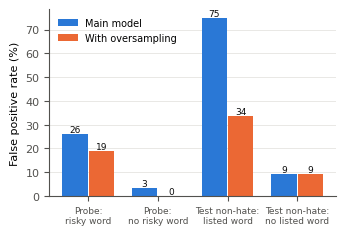

Registered F11 -> figures/fig_11_debias_fpr.png


In [14]:
plt.rcParams.update({'font.size': 8, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
                     'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white'})
groups = ['Probe:\nrisky word', 'Probe:\nno risky word', 'Test non-hate:\nlisted word', 'Test non-hate:\nno listed word']
old_vals = [old_fpr['A'], old_fpr['B'], real['old_with'], real['old_without']]
new_vals = [new_fpr['A'], new_fpr['B'], real['new_with'], real['new_without']]
x = np.arange(len(groups))
fig, ax = plt.subplots(figsize=(3.5, 2.4))
b1 = ax.bar(x - 0.19, old_vals, 0.36, color='#2a78d6', label='Main model')
b2 = ax.bar(x + 0.19, new_vals, 0.36, color='#eb6834', label='With oversampling')
for bars in (b1, b2):
    for rect in bars:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f'{rect.get_height():.0f}',
                ha='center', va='bottom', fontsize=6.5, color='#0b0b0b')
ax.set_xticks(x, groups, fontsize=6.5)
ax.set_ylabel('False positive rate (%)')
ax.grid(axis='y', color='#e5e4e0', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_11_debias_fpr.png'))
plt.show()
register_asset('F11', 'figures/fig_11_debias_fpr.png',
               'False positive rates of the main model vs the oversampled model on probe sentences and real non-hate test comments',
               NOTEBOOK_NAME, 'V. Results (bias mitigation)',
               'Fig. X. False positive rates before and after oversampling non-hate training comments that contain hate-associated words.')

## Save everything (M13)

The model settings go next to the new checkpoint (so the demo could load it), and all numbers go into metrics_debias.json.

In [15]:
cfg_new = {'model_name': CONFIG['model_name'], 'max_length': MAX_LEN, 'dropout': CONFIG['dropout'],
           'categories': TARGET_COLS, 'weights_file': 'best_model.pt',
           'best_epoch': int(log_df.loc[log_df['val_loss'].idxmin(), 'epoch']),
           'binary_threshold': bin_thr, 'category_thresholds': dict(zip(TARGET_COLS, cat_thr.tolist()))}
with open(os.path.join(OUT_DIR, 'model_config.json'), 'w') as f:
    json.dump(cfg_new, f, indent=2)

out = {'step': 'debias', 'notebook': NOTEBOOK_NAME, 'date': datetime.now().isoformat(timespec='seconds'),
       'seed': SEED, 'method': f'oversample non-hate training comments containing a hate-associated word ({REPEAT} extra copies)',
       'word_rule': {'min_count': MIN_COUNT, 'min_hate_rate': MIN_HATE_RATE, 'n_words': len(hate_words)},
       'n_repeated_comments': len(to_repeat), 'train_rows': [len(train_df), len(aug_train)],
       'training_minutes': float(log_df['minutes'].sum()), 'best_epoch': cfg_new['best_epoch'],
       'binary_threshold': bin_thr, 'test_binary': new_bin, 'test_multilabel_hate': new_ml_hate,
       'probe_fpr': {'old': old_fpr, 'new': new_fpr}, 'test_fpr': real,
       'comparison': comparison.to_dict(orient='records'), 'words': hate_words}
with open(os.path.join(REP_DIR, 'metrics_debias.json'), 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=lambda o: o.item() if hasattr(o, 'item') else str(o))
register_asset('M13', 'evaluation_reports/metrics_debias.json (+ training_log_debiased.csv)',
               'All numbers of the bias mitigation experiment: word rule, oversampling size, test scores, false positive rates',
               NOTEBOOK_NAME, 'IV. Methodology / V. Results (bias mitigation)',
               'Not a figure; source for every number of the mitigation experiment.')
print('Saved')

Registered M13 -> evaluation_reports/metrics_debias.json (+ training_log_debiased.csv)
Saved


## Summary

We trained a second model where non-hate training comments containing hate-associated words are shown more often, and compared it with the main model on accuracy and on false positives (T24, F11). The main model stays our main result, and this experiment is reported as an attempt to reduce the bias, whatever the outcome.

## Remember this

- What we did: retrained the model while showing harmless comments with insult-like words more often, then measured accuracy and false alarms again.
- Why: the model had learned "this word means hate", and seeing the words used harmlessly more often should weaken that shortcut.
- Key number: false alarms on real non-hate test comments with these words fell from 74.8% to 33.8%, but category macro-F1 on hate comments dropped from 28.89 to 22.05, so the main model stays our main result.